## Набор данных Футболисты

В качестве задания вам предлагается повторить данные действия для набора данных
- [Blood Transfusion Service Center Data Set](http://archive.ics.uci.edu/ml/datasets/Blood+Transfusion+Service+Center)

In [ ]:
import pandas as pd

Набор данных о футболистах.

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/yakushinav/omo/main/data/data_football_profile.csv', sep='\t')

In [ ]:
df.columns

Index(['Name', 'Age', 'Nationality', 'Club', 'Value', 'Wage'], dtype='object')

Функция возвращает DataFrame (то есть таблицу), однако затем приобретает ещё много важных параметров, среди которых:

* sep — разделитель данных, по умолчанию ',';
* decimal — разделитель числа на целую и дробную часть, по умолчанию'.';
* names — список с названиями колонок, не обязательный параметр;
* skiprows — если файл содержит системную информацию, можно просто её пропустить. Необязательный параметр.

С помощью функции ```head``` можем посмотреть на первые несколько строк нашего датасета:

In [ ]:
df.head()

,Name,Age,Nationality,Club,Value,Wage
0,L. Messi,31.0,Argentina,FC Barcelona,110500000.0,"565000,0$"
1,NaN,33.0,Portugal,Juventus,77000000.0,"405000,0$"
2,Neymar Jr,26.0,Brazil,Paris Saint-Germain,118500000.0,"290000,0$"
3,De Gea,27.0,Spain,Manchester United,72000000.0,"260000,0$"
4,K. De Bruyne,27.0,Belgium,Manchester City,102000000.0,"355000,0$"


Удалим колонку Value, к которой мы не знаем точную интерпретацию:

In [ ]:
df.drop(['Value'], axis=1, inplace=True)

In [ ]:
# последние несколько строк:
df.tail(3)

,Name,Age,Nationality,Club,Wage
12894,NaN,16.0,England,Cambridge United,"1000,0$"
12895,D. Walker-Rice,17.0,England,Tranmere Rovers,"1000,0$"
12896,G. Nugent,16.0,England,Tranmere Rovers,"1000,0$"


Посмотрим на размер нашего датасета. Первое число – количество строк (наблюдений), второе – количество столбцов (признаков):

In [ ]:
df.shape

(12897, 5)

Если вы хотите переименовать какую-то переменную, воспользуйтесь ```rename```:

In [ ]:
df.rename({'Wage' : 'Salary'}, axis='columns', inplace=True)

In [ ]:
df.columns

Index(['Name', 'Age', 'Nationality', 'Club', 'Salary'], dtype='object')

Давайте посмотрим на информацию о датасете. В .info() можно передать дополнительные параметры, среди которых:

* verbose: печатать ли информацию о DataFrame полностью (если таблица очень большая, то некоторая информация может потеряться);
* memory_usage: печатать ли потребление памяти (по умолчанию используется True, но можно поставить либо False, что уберёт потребление памяти, либо 'deep' , что подсчитает потребление памяти более точно);
* null_counts: подсчитывать ли количество пустых элементов (по умолчанию True).

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12897 entries, 0 to 12896
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Name         12266 non-null  object 
 1   Age          12242 non-null  float64
 2   Nationality  12213 non-null  object 
 3   Club         12226 non-null  object 
 4   Salary       12897 non-null  object 
dtypes: float64(1), object(4)
memory usage: 503.9+ KB


Можно вывести только тип данных в каждой колонке:

In [ ]:
df.dtypes

,0
Name,object
Age,float64
Nationality,object
Club,object
Salary,object


Заметим, что зарплата у нас записана строкой.

In [ ]:
def fix_wage(x):
    # отрезаем $
    x = x[:-1]
    # меняем запятую на точку
    x = x.replace(',', '.')
    return float(x)

In [ ]:
df['Salary'] = df['Salary'].apply(fix_wage)

Метод describe показывает основные статистические характеристики данных по каждому числовому признаку (типы int64 и float64): число непропущенных значений, среднее, стандартное отклонение, диапазон, медиану, 0.25 и 0.75 квартили.

In [ ]:
df.describe()

,Age,Salary
count,12242.000000,12263.000000
mean,24.814900,7530.946750
std,4.885492,23338.219396
min,16.000000,1000.000000
25%,21.000000,1000.000000
50%,24.000000,2000.000000
75%,28.000000,4000.000000
max,45.000000,565000.000000


Чтобы посмотреть статистику по нечисловым признакам (например, по строчным (object) или булевым (bool) данным), нужно явно указать интересующие нас типы в параметре метода describe include:

In [ ]:
df.describe(include = ['object'])

,Name,Nationality,Club
count,12266,12213,12226
unique,11742,155,650
top,J. Rodríguez,England,Shonan Bellmare
freq,7,1297,30


Было бы полезно узнать, много ли у нас пропусков в датасете.

In [ ]:
df.isna().sum()
print(df.dtypes)

Name            object
Age            float64
Nationality     object
Club            object
Salary         float64
dtype: object


Чтобы удалить пропуски из данных, нужно вопспользоваться ```df.dropna()```, либо заполнить их значениями (например, средним) -  ```df.fillna(df['column_name'].mean())``` .
Если в датасете содержатся дубликаты строк - воспользуйтесь методом ```df.drop_duplicates()```.

In [ ]:
# заполним количественные переменные средними значениями (медианой)
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Salary'] = df['Salary'].fillna(df['Salary'].median())

# у оставшихся переменных удалим строки с пропусками
df.dropna(inplace=True)

df.isna().sum()

,0
Name,0
Age,0
Nationality,0
Club,0
Salary,0


Выведем уникальные значения по возрасту и сколько раз каждое из них встречается в датасете (по убыванию).

In [ ]:
df['Age'].value_counts()

,count
Age,
24.0,1288
21.0,876
22.0,808
20.0,786
19.0,724
23.0,715
25.0,693
26.0,688
27.0,616


Чтобы вывести уникальные значения в столбце или их количество, нужно использовать ```unique``` и ```nunique``` соответственно. Посмотрим, сколько у нас уникальных футбольных клубов.

In [ ]:
print('Всего {} футбольных клубов'.format(df['Club'].nunique()))

Всего 650 футбольных клубов


In [ ]:
df['Club'].unique()[:10]

array(['FC Barcelona', 'Paris Saint-Germain', 'Manchester United',
       'Manchester City', 'Chelsea', 'Real Madrid', 'Atlético Madrid',
       'FC Bayern München', 'Juventus', 'Liverpool'], dtype=object)

Посмотрим на среднюю зарплату по клубу:

In [ ]:
grouped = df.groupby('Club', as_index=False)['Salary'].mean()
# добавим сортировку по убыванию
grouped.sort_values(by='Salary', ascending=False)

,Club,Salary
469,Real Madrid,187500.000000
212,FC Barcelona,184722.222222
325,Juventus,148461.538462
373,Manchester City,137761.904762
134,Chelsea,103894.736842
...,...,...
531,Shamrock Rovers,1000.000000
92,Bray Wanderers,1000.000000
90,Boyacá Chicó FC,1000.000000
548,Spartak Moscow,1000.000000


Добавим еще подсчет минимума, максимума и медианы по каждой группе:

In [ ]:
df.groupby('Club')['Salary'].agg(['mean', 'min', 'max', 'median'])

,mean,min,max,median
Club,,,,
SSV Jahn Regensburg,3222.222222,1000.0,6000.0,3000.0
1. FC Heidenheim 1846,4000.000000,1000.0,14000.0,3000.0
1. FC Kaiserslautern,1454.545455,1000.0,3000.0,1000.0
1. FC Köln,9200.000000,1000.0,26000.0,4000.0
1. FC Magdeburg,3842.105263,1000.0,8000.0,4000.0
...,...,...,...,...
Zagłębie Sosnowiec,1047.619048,1000.0,2000.0,1000.0
Çaykur Rizespor,5095.238095,1000.0,13000.0,4000.0
Örebro SK,1454.545455,1000.0,2000.0,1000.0


Сгруппируем одновременно по стране и клубу:

In [ ]:
df.groupby(['Nationality', 'Club'], as_index=False)['Salary'].mean()

,Nationality,Club,Salary
0,Afghanistan,Notts County,2000.0
1,Afghanistan,SV Meppen,1000.0
2,Afghanistan,Walsall,1000.0
3,Albania,AC Ajaccio,2000.0
4,Albania,Aalborg BK,1000.0
...,...,...,...
3242,Zimbabwe,Club Brugge KV,20000.0
3243,Zimbabwe,Hobro IK,5000.0
3244,Zimbabwe,Le Havre AC,2000.0
3245,Zimbabwe,Orlando Pirates,1000.0


Добавим сортировку внутри групп:

In [ ]:
df.groupby(['Nationality', 'Club']).apply(lambda x: x.sort_values(by='Salary', ascending=False))

/tmp/ipykernel_6536/438706912.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby(['Nationality', 'Club']).apply(lambda x: x.sort_values(by='Salary', ascending=False))


Name   Age  Nationality  \
Nationality Club                                                      
Afghanistan Notts County    10007       N. Husin  21.0  Afghanistan   
            SV Meppen       7695         H. Amin  26.0  Afghanistan   
            Walsall         8395      M. Kouhyar  20.0  Afghanistan   
Albania     AC Ajaccio      4697         Q. Laçi  22.0      Albania   
            Aalborg BK      12510      B. Bytyqi  21.0      Albania   
...                                          ...   ...          ...   
Zimbabwe    Club Brugge KV  468       M. Nakamba  24.0     Zimbabwe   
            Hobro IK        2772      Q. Antipas  34.0     Zimbabwe   
            Le Havre AC     6090     T. Kadewere  22.0     Zimbabwe   
            Orlando Pirates 6502      M. Munetsi  24.0     Zimbabwe   
            Sparta Praha    1750   C. Nhamoinesu  32.0     Zimbabwe   

                                              Club   Salary  
Nationality Club                                             
Afghanistan Notts County    10007     Notts County   2000.0  
            SV Meppen       7695         SV Meppen   1000.0  
            Walsall         8395           Walsall   1000.0  
Albania     AC Ajaccio      4697        AC Ajaccio   2000.0  
            Aalborg BK      12510       Aalborg BK   1000.0  
...                                            ...      ...  
Zimbabwe    Club Brugge KV  468     Club Brugge KV  20000.0  
            Hobro IK        2772          Hobro IK   5000.0  
            Le Havre AC     6090       Le Havre AC   2000.0  
            Orlando Pirates 6502   Orlando Pirates   1000.0  
            Sparta Praha    1750      Sparta Praha   1000.0  

[11007 rows x 5 columns]

Теперь удалим лишние колонки. Обратите внимание на обратный слэш, это line continuation character.

In [ ]:
df.groupby(['Nationality', 'Club']).apply(lambda x: x.sort_values(by='Salary', ascending=False)).\
                                                    drop(['Nationality', 'Club'], axis=1)

/tmp/ipykernel_6536/824076035.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby(['Nationality', 'Club']).apply(lambda x: x.sort_values(by='Salary', ascending=False)).\


Name   Age   Salary
Nationality Club                                               
Afghanistan Notts County    10007       N. Husin  21.0   2000.0
            SV Meppen       7695         H. Amin  26.0   1000.0
            Walsall         8395      M. Kouhyar  20.0   1000.0
Albania     AC Ajaccio      4697         Q. Laçi  22.0   2000.0
            Aalborg BK      12510      B. Bytyqi  21.0   1000.0
...                                          ...   ...      ...
Zimbabwe    Club Brugge KV  468       M. Nakamba  24.0  20000.0
            Hobro IK        2772      Q. Antipas  34.0   5000.0
            Le Havre AC     6090     T. Kadewere  22.0   2000.0
            Orlando Pirates 6502      M. Munetsi  24.0   1000.0
            Sparta Praha    1750   C. Nhamoinesu  32.0   1000.0

[11007 rows x 3 columns]

Посчитаем арифметическое среднее, моду и медиану возраста футболистов (количественной переменной):

In [ ]:
print('Среднее:', round(df['Age'].mean(), 2),
      'Медиана:', df['Age'].median(),
      'Мода:', df['Age'].mode()[0])

Среднее: 24.78 Медиана: 24.0 Мода: 24.0


Для качественных переменных с помощью pandas можно вывести моду. Посмотрим на самую часто встречающуюся национальность:

In [ ]:
df['Nationality'].mode()

,Nationality
0,England


Часто возникает необходимость выбрать данные из DataFrame по определённому условию. Например, если в уже известном нам наборе данных о футболистах мы хотим выбрать только тех, у кого возраст больше 20 лет, используется следующий код:

In [ ]:
df[df.Age > 20]

,Name,Age,Nationality,Club,Salary
0,L. Messi,31.0,Argentina,FC Barcelona,565000.0
2,Neymar Jr,26.0,Brazil,Paris Saint-Germain,290000.0
3,De Gea,27.0,Spain,Manchester United,260000.0
4,K. De Bruyne,27.0,Belgium,Manchester City,355000.0
5,E. Hazard,27.0,Belgium,Chelsea,340000.0
...,...,...,...,...,...
12838,D. Mackay,21.0,Scotland,Kilmarnock,1000.0
12855,H. Norris,24.0,England,Oldham Athletic,1000.0
12861,Y. Uchimura,33.0,Japan,Hokkaido Consadole Sapporo,1000.0
12873,K. Pilkington,44.0,England,Cambridge United,1000.0


Выберем футболистов, возраст которых больше среднего возраста футболистов, при условии, что они принадлежат ФК Барселона (Club == 'FC Barcelona').

In [ ]:
df[(df.Age > df.Age.mean()) & (df.Club == 'FC Barcelona')]

,Name,Age,Nationality,Club,Salary
0,L. Messi,31.0,Argentina,FC Barcelona,565000.0
7,L. Suárez,31.0,Uruguay,FC Barcelona,455000.0
18,M. ter Stegen,26.0,Germany,FC Barcelona,240000.0
20,Sergio Busquets,29.0,Spain,FC Barcelona,315000.0
32,Coutinho,26.0,Brazil,FC Barcelona,340000.0
49,Jordi Alba,29.0,Spain,FC Barcelona,250000.0
54,Piqué,31.0,Spain,FC Barcelona,240000.0
204,J. Cillessen,29.0,Netherlands,FC Barcelona,135000.0
605,T. Vermaelen,32.0,Belgium,FC Barcelona,2000.0


Чтобы объединить данные из нескольких датасетов по ключу (общей колонке), в pandas можно воспользовать встроенными аналогами SQL методов. В метод ```join``` в качестве аргумента how нужно указать тип объединения датасетов: inner, outer, left или right.

In [ ]:
df_info = pd.read_csv('https://raw.githubusercontent.com/yakushinav/omo/main/data/data_football_info.csv', sep='\t')

joined_dfs = df_info.set_index('Name').join(df.set_index('Name'), how='inner').reset_index()
joined_dfs.head(5)

,Name,Unnamed: 0,Position,Crossing,Finishing,HeadingAccuracy,ShortPassing,Volleys,Dribbling,Curve,...,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes,Age,Nationality,Club,Salary
0,L. Messi,0.0,RF,84.0,95.0,NaN,90.0,86.0,97.0,93.0,...,26.0,6.0,11.0,15.0,NaN,NaN,31.0,Argentina,FC Barcelona,565000.0
1,Neymar Jr,2.0,LW,79.0,87.0,62.0,84.0,84.0,96.0,88.0,...,33.0,9.0,9.0,15.0,15.0,11.0,26.0,Brazil,Paris Saint-Germain,290000.0
2,De Gea,3.0,GK,17.0,13.0,21.0,50.0,13.0,18.0,21.0,...,13.0,90.0,85.0,87.0,88.0,94.0,27.0,Spain,Manchester United,260000.0
3,K. De Bruyne,4.0,RCM,93.0,82.0,55.0,92.0,82.0,86.0,85.0,...,51.0,15.0,13.0,5.0,NaN,13.0,27.0,Belgium,Manchester City,355000.0
4,E. Hazard,5.0,NaN,81.0,84.0,61.0,89.0,80.0,95.0,83.0,...,22.0,11.0,12.0,6.0,8.0,8.0,27.0,Belgium,Chelsea,340000.0


В качестве задания вам предлагается повторить данные действия по визуализации и классификации для набора данных
- [Blood Transfusion Service Center Data Set](http://archive.ics.uci.edu/ml/datasets/Blood+Transfusion+Service+Center)

In [ ]:
# 1. Импорт необходимых библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# для классификации
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# настройка отображения графиков
%matplotlib inline
sns.set_style('whitegrid')

In [ ]:
# 2. Загрузка данных (UCI Machine Learning Repository)
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/blood-transfusion/transfusion.data'
df = pd.read_csv(url)

# Посмотрим на первые строки
df.head()

,Recency (months),Frequency (times),Monetary (c.c. blood),Time (months),whether he/she donated blood in March 2007
0,2,50,12500,98,1
1,0,13,3250,28,1
2,1,16,4000,35,1
3,2,20,5000,45,1
4,1,24,6000,77,0


In [ ]:
# 3. Информация о датасете
print("Размер данных:", df.shape)
df.info()

Размер данных: (748, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 748 entries, 0 to 747
Data columns (total 5 columns):
 #   Column                                      Non-Null Count  Dtype
---  ------                                      --------------  -----
 0   Recency (months)                            748 non-null    int64
 1   Frequency (times)                           748 non-null    int64
 2   Monetary (c.c. blood)                       748 non-null    int64
 3   Time (months)                               748 non-null    int64
 4   whether he/she donated blood in March 2007  748 non-null    int64
dtypes: int64(5)
memory usage: 29.3 KB


In [ ]:
# 4. Проверка пропусков
print("Пропуски в каждом столбце:\n", df.isna().sum())

Пропуски в каждом столбце:
 Recency (months)                              0
Frequency (times)                             0
Monetary (c.c. blood)                         0
Time (months)                                 0
whether he/she donated blood in March 2007    0
dtype: int64


In [ ]:
# 5. Описательные статистики для числовых признаков
df.describe()

,Recency (months),Frequency (times),Monetary (c.c. blood),Time (months),whether he/she donated blood in March 2007
count,748.000000,748.000000,748.000000,748.000000,748.000000
mean,9.506684,5.514706,1378.676471,34.282086,0.237968
std,8.095396,5.839307,1459.826781,24.376714,0.426124
min,0.000000,1.000000,250.000000,2.000000,0.000000
25%,2.750000,2.000000,500.000000,16.000000,0.000000
50%,7.000000,4.000000,1000.000000,28.000000,0.000000
75%,14.000000,7.000000,1750.000000,50.000000,0.000000
max,74.000000,50.000000,12500.000000,98.000000,1.000000


In [ ]:
# 6. Переименуем столбцы для удобства (оригинальные названия длинные)
df.columns = ['Recency', 'Frequency', 'Monetary', 'Time', 'Donated_Mar2007']
# Recency – месяцы с последнего донации
# Frequency – общее число донаций
# Monetary – общий объём сданной крови (куб. см)
# Time – месяцы с первой донации
# Donated_Mar2007 – целевая переменная (1 = сдал кровь в марте 2007)
df.head()

,Recency,Frequency,Monetary,Time,Donated_Mar2007
0,2,50,12500,98,1
1,0,13,3250,28,1
2,1,16,4000,35,1
3,2,20,5000,45,1
4,1,24,6000,77,0


In [ ]:
# 7. Анализ целевой переменной
print("Распределение классов:\n", df['Donated_Mar2007'].value_counts())
print("Доля сдавших кровь:", df['Donated_Mar2007'].mean())

Распределение классов:
 Donated_Mar2007
0    570
1    178
Name: count, dtype: int64
Доля сдавших кровь: 0.23796791443850268


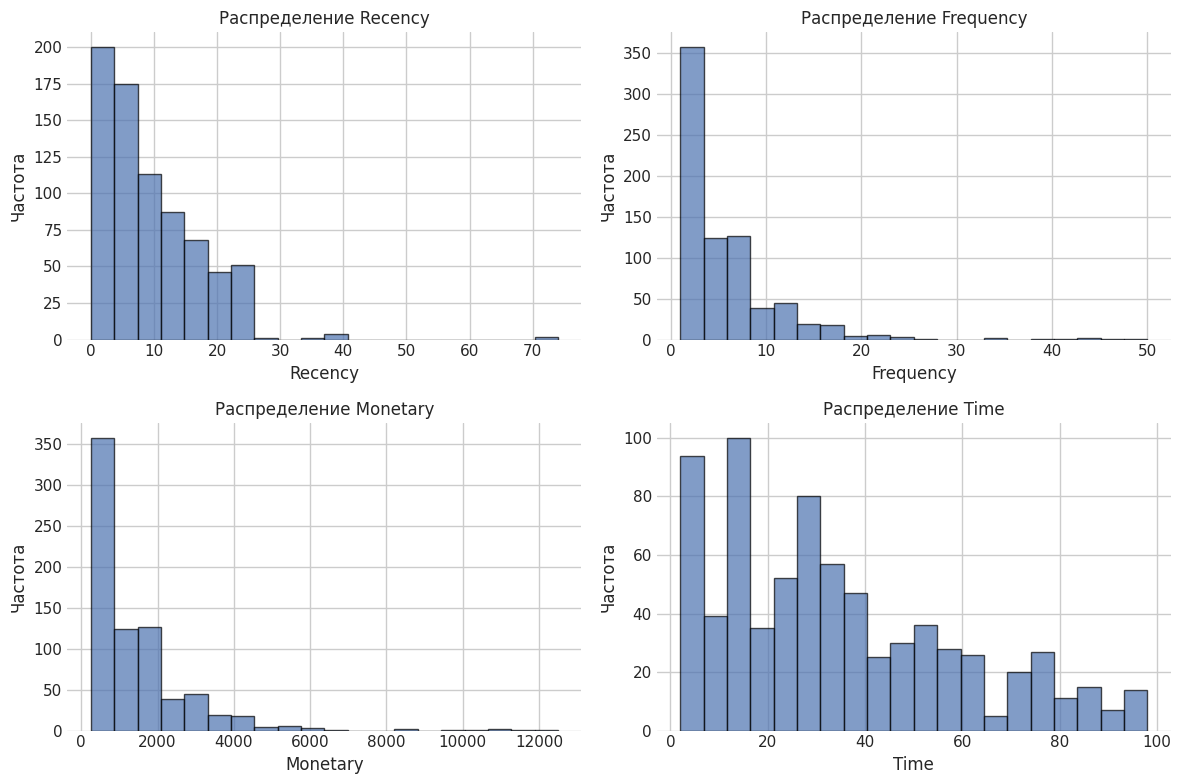

In [ ]:
# 8. Визуализация распределений признаков
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

features = ['Recency', 'Frequency', 'Monetary', 'Time']
for i, col in enumerate(features):
    axes[i].hist(df[col], bins=20, edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Распределение {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Частота')

plt.tight_layout()
plt.show()

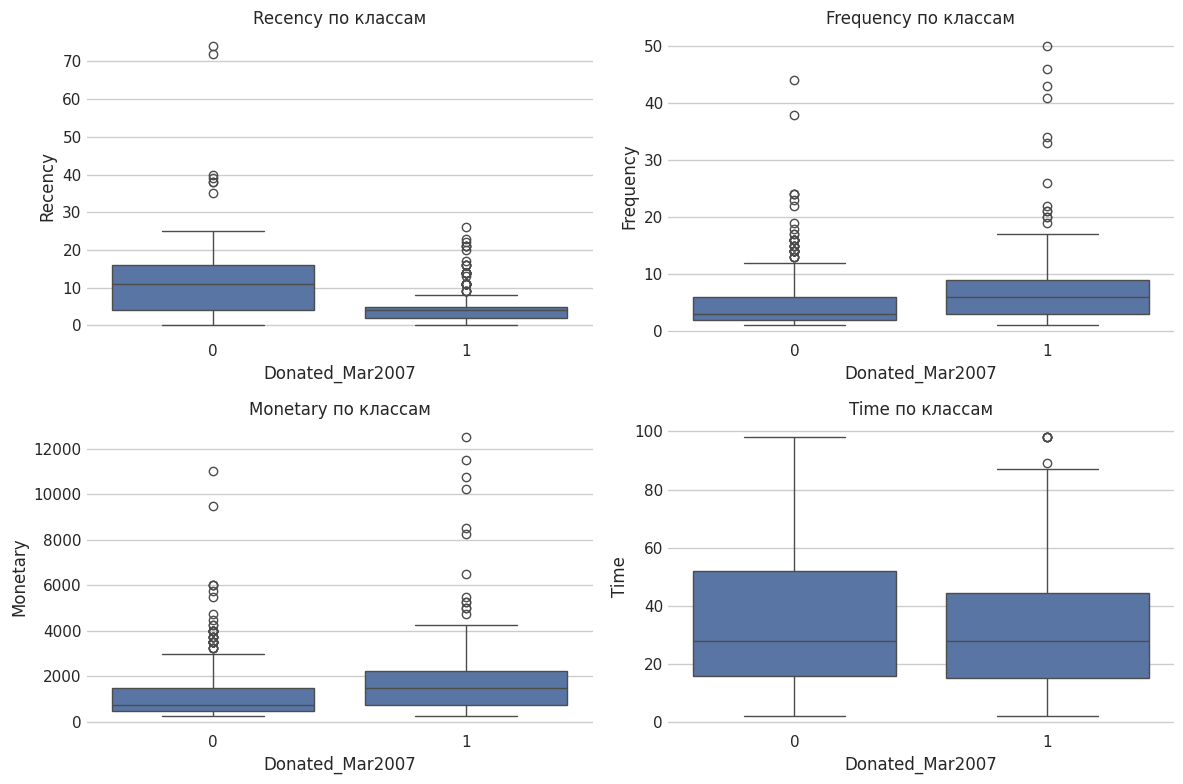

In [ ]:
# 9. Boxplot признаков в зависимости от класса
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for i, col in enumerate(features):
    sns.boxplot(x='Donated_Mar2007', y=col, data=df, ax=axes[i])
    axes[i].set_title(f'{col} по классам')

plt.tight_layout()
plt.show()

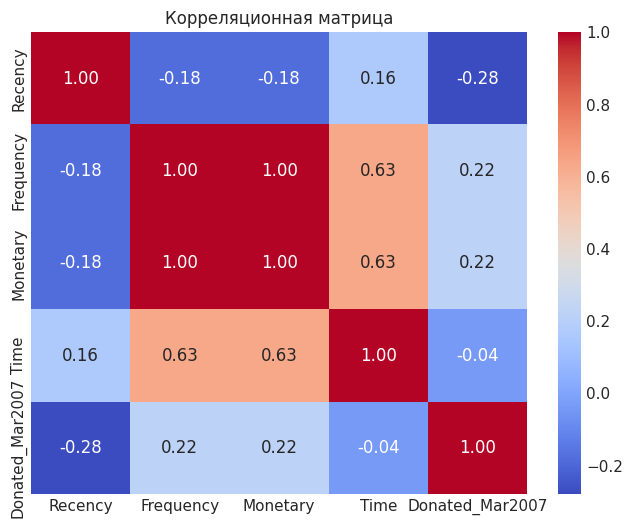

In [ ]:
# 10. Корреляционная матрица
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Корреляционная матрица')
plt.show()

In [ ]:
# 11. Группировка по целевому признаку – средние значения
grouped = df.groupby('Donated_Mar2007').agg(['mean', 'median', 'std'])
grouped.round(2)

Recency              Frequency              Monetary          \
                   mean median   std      mean median   std     mean  median   
Donated_Mar2007                                                                
0                 10.77   11.0  8.43       4.8    3.0  4.75  1200.44   750.0   
1                  5.46    4.0  5.17       7.8    6.0  8.04  1949.44  1500.0   

                           Time                
                     std   mean median    std  
Donated_Mar2007                                
0                1186.69  34.77   28.0  24.61  
1                2009.22  32.72   28.0  23.63

In [ ]:
# 12. Фильтрация – например, люди, сдавшие кровь недавно (Recency <= 6 месяцев)
recent_donors = df[df['Recency'] <= 6]
print("Количество недавних доноров:", len(recent_donors))
print("Доля сдавших в марте среди них:", recent_donors['Donated_Mar2007'].mean())

Количество недавних доноров: 367
Доля сдавших в марте среди них: 0.37329700272479566


In [ ]:
# 13. Подготовка к классификации
X = df[['Recency', 'Frequency', 'Monetary', 'Time']]
y = df['Donated_Mar2007']

# Разделение на обучающую и тестовую выборки (70% / 30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [ ]:
# 14. Логистическая регрессия (простая классификация)
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Точность на тесте:", accuracy_score(y_test, y_pred))
print("\nМатрица ошибок:\n", confusion_matrix(y_test, y_pred))
print("\nОтчёт о классификации:\n", classification_report(y_test, y_pred))

Точность на тесте: 0.7688888888888888

Матрица ошибок:
 [[168   3]
 [ 49   5]]

Отчёт о классификации:
               precision    recall  f1-score   support

           0       0.77      0.98      0.87       171
           1       0.62      0.09      0.16        54

    accuracy                           0.77       225
   macro avg       0.70      0.54      0.51       225
weighted avg       0.74      0.77      0.70       225



In [ ]:
# 15. Дерево решений для сравнения
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(max_depth=3, random_state=42)
tree.fit(X_train, y_train)
y_pred_tree = tree.predict(X_test)

print("Точность дерева решений:", accuracy_score(y_test, y_pred_tree))

Точность дерева решений: 0.7866666666666666
